# Balanced QuantAgents-style reproduction

An honest risk/return experiment using a fixed Nasdaq-30 panel. Model selection
is completed on data through 2020; the 2021-2023 holdout is opened only after
the configuration is frozen.

**Research question.** Can a simple, causal cross-sectional strategy deliver a
solid middle ground between an unlevered baseline and an aggressively levered
paper-matching variant?

In [1]:
from pathlib import Path
from dataclasses import asdict
import json
import inspect
import sys

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.experiment import HOLDOUT, VALIDATION, run_experiment
from src.balanced_quantagents import select_configuration

artifacts = run_experiment(ROOT)
print(f"Project: {ROOT}")
print(f"Validation: {VALIDATION[0]} to {VALIDATION[1]}")
print(f"Locked holdout: {HOLDOUT[0]} to {HOLDOUT[1]}")
print("Selection objective: balanced risk-adjusted validation; paper metrics excluded")

Project: /Users/vladimirkalinovski/Desktop/ISSUE_4
Validation: 2018-01-01 to 2020-12-31
Locked holdout: 2021-01-01 to 2023-12-31
Selection objective: balanced risk-adjusted validation; paper metrics excluded


## 1. Data audit

The run uses frozen local snapshots for deterministic reproduction. Prices are
adjusted closes; no API call occurs during model selection or holdout testing.

In [2]:
close = artifacts["close"]
data_audit = pd.Series({
    "First date": close.index.min().date(),
    "Last date": close.index.max().date(),
    "Trading days": len(close),
    "Assets": close.shape[1],
    "Missing adjusted closes": int(close.isna().sum().sum()),
}, name="Value")
display(data_audit.to_frame())

,Value
First date,2010-01-04
Last date,2023-12-29
Trading days,3522
Assets,30
Missing adjusted closes,0


## 2. Selection protocol

- Monthly, long-only momentum ranking.
- Candidate lookbacks: 60 and 120 trading days; optional 21-day skip.
- Top 5, 8, or 10 assets; equal or inverse-volatility weights.
- Volatility budgets from 26% to 32%, with gross exposure capped at 1.25x or 1.50x.
- A causal drawdown governor uses only the previous day's state.
- 10 bps one-way turnover cost is charged throughout.
- Final constraints on 2018-2020: ARR at least 30%, annual volatility at most 36%, max drawdown at most 30%.

The score combines validation Sharpe and Calmar, rolling-window stability, and
a turnover penalty. It contains no article target and no 2021-2023 statistic.

In [3]:
signal = artifacts["signal"]
risk = artifacts["risk"]
selection = pd.Series({
    "Momentum lookback": signal.lookback,
    "Skip": signal.skip,
    "Selected assets": signal.top_n,
    "Inverse-volatility weighting": signal.inverse_vol,
    "Target volatility": risk.target_vol,
    "Maximum gross exposure": risk.max_gross,
    "Risk-off multiplier": risk.risk_off_multiplier,
    "Soft / hard drawdown": f"{risk.soft_drawdown:.0%} / {risk.hard_drawdown:.0%}",
    "Soft / hard exposure multiplier": f"{risk.soft_multiplier:.2f} / {risk.hard_multiplier:.2f}",
}, name="Selected value")
display(selection.to_frame())

,Selected value
Momentum lookback,120
Skip,0
Selected assets,8
Inverse-volatility weighting,False
Target volatility,0.32
Maximum gross exposure,1.25
Risk-off multiplier,1.0
Soft / hard drawdown,-10% / -20%
Soft / hard exposure multiplier,0.85 / 0.65


In [4]:
leaderboard_columns = [
    "signal_lookback", "signal_skip", "signal_top_n", "signal_inverse_vol",
    "risk_target_vol", "risk_max_gross", "risk_risk_off_multiplier",
    "risk_soft_drawdown", "risk_hard_drawdown", "validation_score",
    "validation_arr", "validation_sharpe", "validation_max_drawdown",
    "validation_volatility", "annual_turnover",
]
top_validation = artifacts["leaderboard"].loc[:9, leaderboard_columns].copy()
for column in ["validation_arr", "validation_max_drawdown", "validation_volatility"]:
    top_validation[column] = (100 * top_validation[column]).map(lambda x: f"{x:.2f}%")
for column in ["validation_score", "validation_sharpe", "annual_turnover"]:
    top_validation[column] = top_validation[column].map(lambda x: f"{x:.3f}")
display(top_validation)

,signal_lookback,signal_skip,signal_top_n,signal_inverse_vol,risk_target_vol,risk_max_gross,risk_risk_off_multiplier,risk_soft_drawdown,risk_hard_drawdown,validation_score,validation_arr,validation_sharpe,validation_max_drawdown,validation_volatility,annual_turnover
0,120,0,8,False,0.32,1.25,1.0,-0.10,-0.2,1.141,37.69%,1.236,27.36%,29.40%,10.550
1,120,0,8,False,0.32,1.25,1.0,-0.12,-0.2,1.135,38.09%,1.228,28.22%,29.99%,10.224
2,120,0,8,False,0.30,1.25,1.0,-0.10,-0.2,1.134,36.49%,1.238,26.80%,28.43%,10.424
3,120,0,8,False,0.30,1.25,1.0,-0.12,-0.2,1.132,36.89%,1.230,27.32%,28.97%,10.111
4,120,0,8,False,0.32,1.25,0.9,-0.10,-0.2,1.132,37.04%,1.234,27.17%,28.96%,10.991
5,120,0,8,False,0.32,1.25,0.9,-0.12,-0.2,1.130,37.39%,1.226,27.75%,29.49%,10.691
6,120,0,8,False,0.28,1.25,1.0,-0.10,-0.2,1.128,35.21%,1.243,26.17%,27.28%,10.345
7,120,0,8,False,0.28,1.25,1.0,-0.12,-0.2,1.127,35.61%,1.237,26.64%,27.78%,10.049
8,120,0,8,False,0.30,1.25,0.9,-0.10,-0.2,1.125,35.86%,1.235,26.63%,28.02%,10.842
9,120,0,8,False,0.30,1.25,0.9,-0.12,-0.2,1.124,36.20%,1.228,27.15%,28.51%,10.555


## 3. Locked holdout results

The selected configuration is now evaluated once on 2021-2023. `Balanced
strategy` includes the selected risk controls and all modeled transaction costs.

In [5]:
performance = artifacts["performance"].copy()
for column in ["Total Return", "ARR", "Annual Volatility", "Max Drawdown"]:
    performance[column] = (100 * performance[column]).map(lambda x: f"{x:.2f}%")
for column in ["Sharpe", "Sortino", "Calmar"]:
    performance[column] = performance[column].map(lambda x: f"{x:.3f}")
display(performance)

,Total Return,ARR,Annual Volatility,Sharpe,Sortino,Max Drawdown,Calmar
Balanced strategy,84.22%,22.69%,25.98%,0.917,1.340,35.20%,0.645
Unscaled selected signal,74.92%,20.58%,25.96%,0.851,1.242,36.35%,0.566
Equal Weight 30,64.85%,18.21%,22.88%,0.846,1.234,30.79%,0.591
QQQ benchmark,33.04%,10.02%,23.76%,0.521,0.742,35.12%,0.285


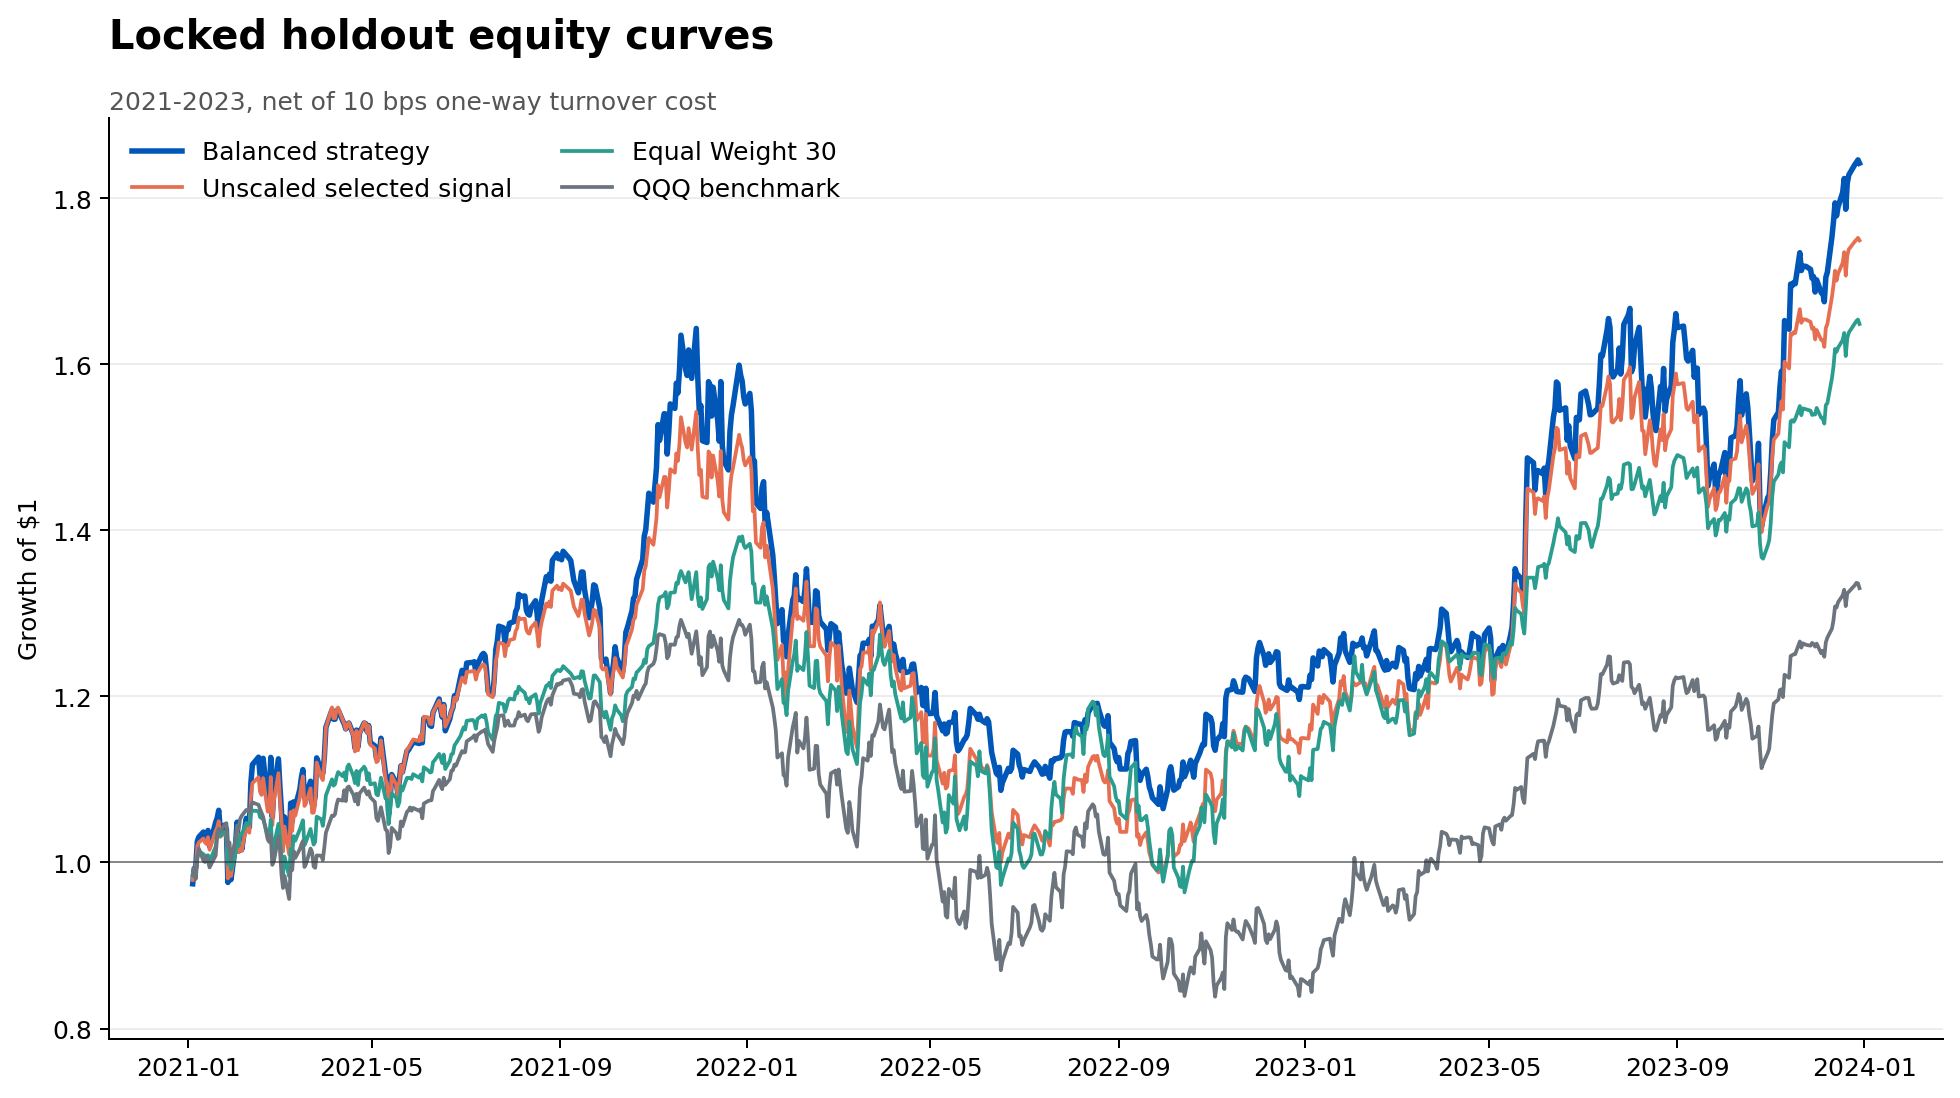

In [6]:
display(Image(filename=str(ROOT / "figures" / "equity_curves.png"), width=980))

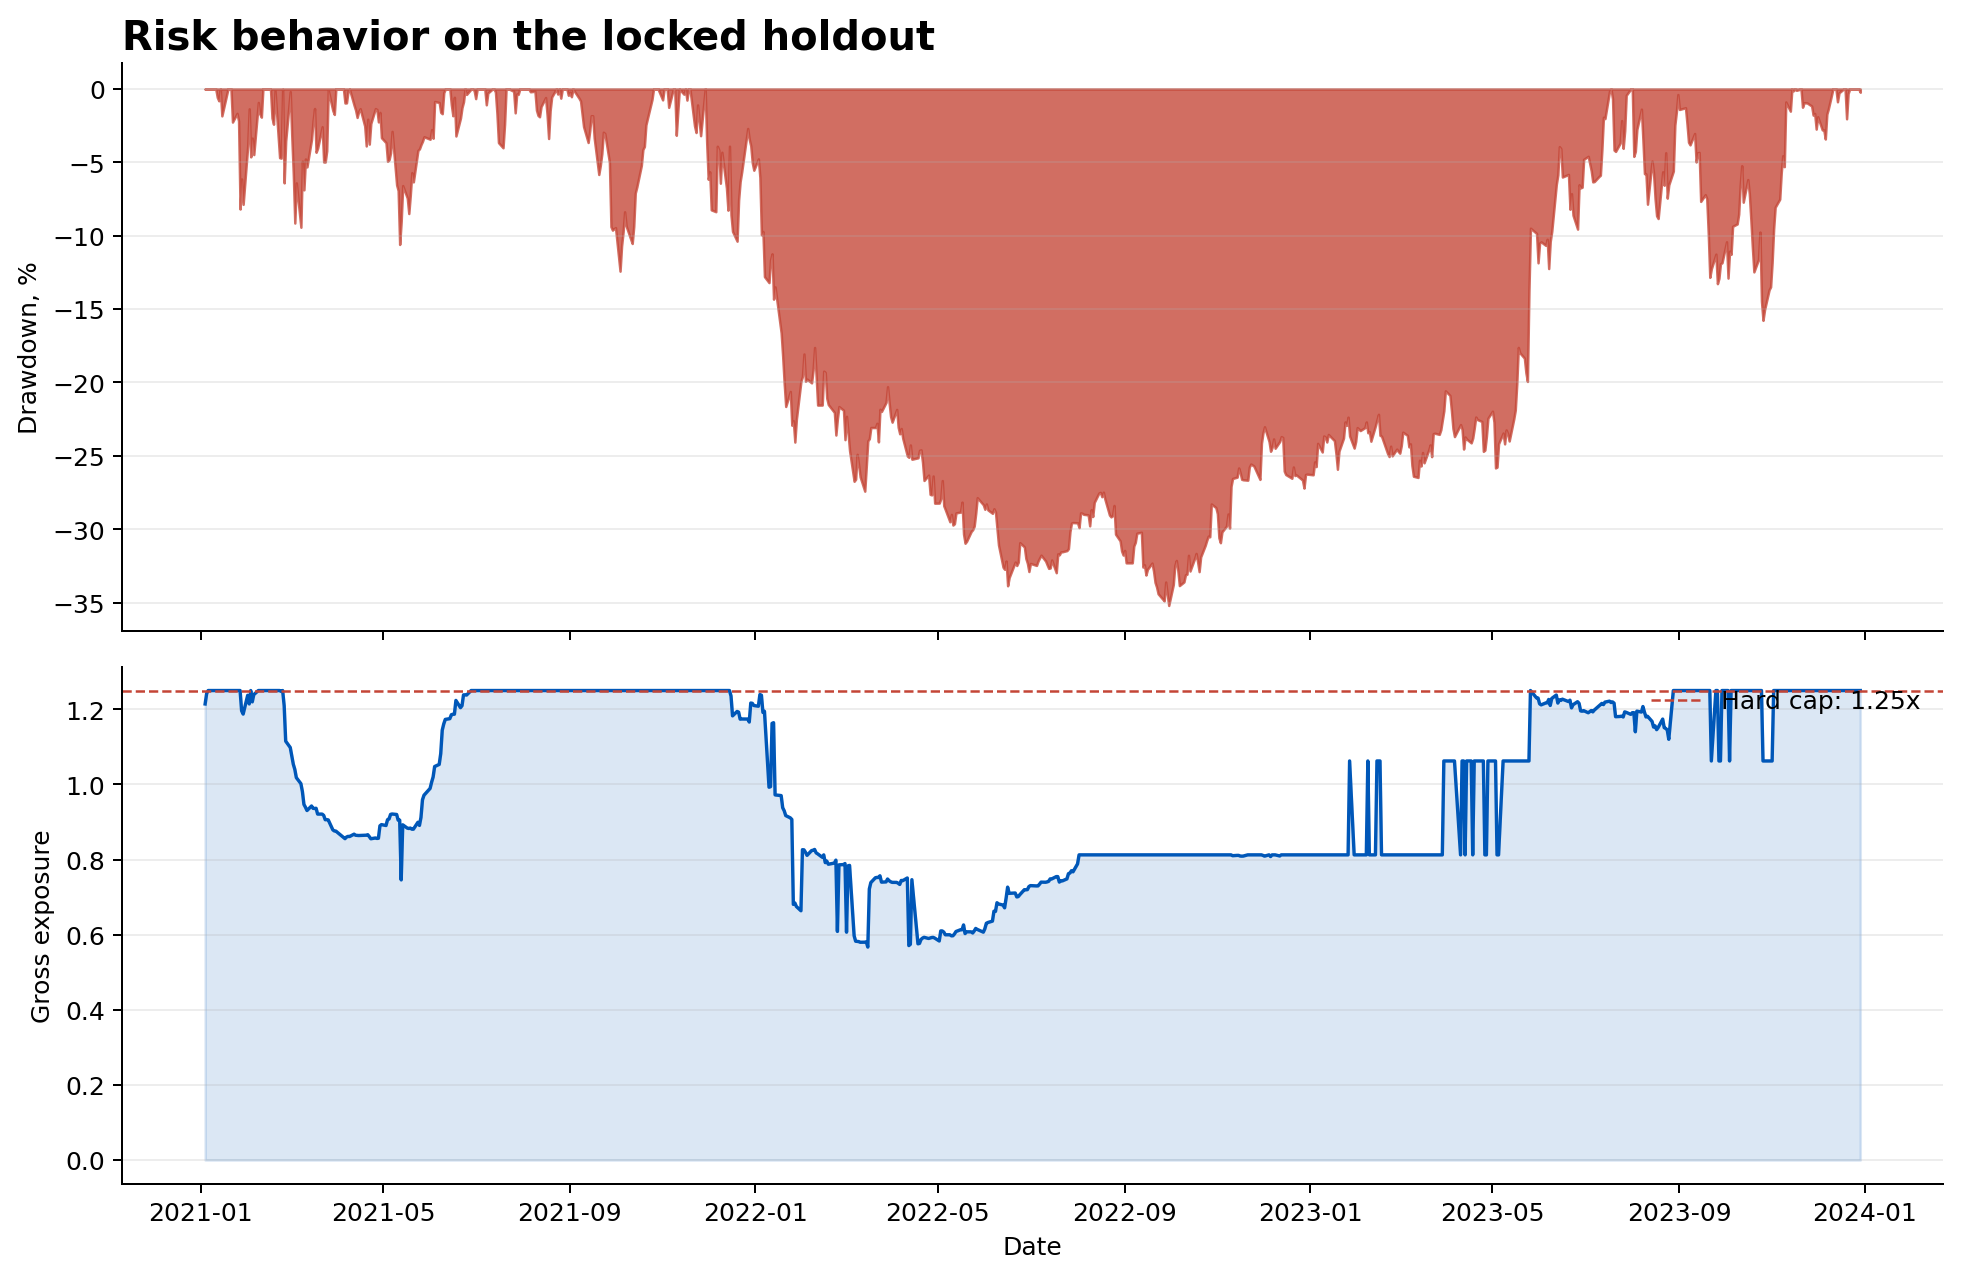

In [7]:
display(Image(filename=str(ROOT / "figures" / "drawdown_and_exposure.png"), width=980))

## 4. Year-by-year and stress audit

Yearly decomposition prevents one strong subperiod from hiding the rest. The
stress table reports tail observations, exposure, turnover, and modeled costs.

In [8]:
annual = (100 * artifacts["annual"]).map(lambda x: f"{x:.2f}%")
display(annual)

stress = artifacts["stress"].copy()
percent_rows = [
    "Worst day", "Best day", "Monthly 5% quantile", "Worst month",
    "Positive month share", "Daily VaR 95%", "Daily CVaR 95%",
    "Cumulative cost / initial capital",
]
for row in percent_rows:
    stress.loc[row] = stress.loc[row].map(lambda x: f"{100 * float(x):.2f}%")
for row in ["Average gross exposure", "Maximum gross exposure", "Annual turnover"]:
    stress.loc[row] = stress.loc[row].map(lambda x: f"{float(x):.3f}")
display(stress)

,Balanced strategy,Unscaled selected signal,Equal Weight 30,QQQ benchmark
Year,,,,
2021,55.22%,47.82%,37.87%,27.42%
2022,-21.92%,-22.20%,-20.03%,-32.58%
2023,52.00%,52.10%,49.51%,54.86%


/var/folders/8x/l3fwqbrd0wd5tlj4qj0z0xqw0000gn/T/ipykernel_26972/4211364182.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-6.37%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  stress.loc[row] = stress.loc[row].map(lambda x: f"{100 * float(x):.2f}%")


,Balanced strategy
Worst day,-6.37%
Best day,7.70%
Monthly 5% quantile,-9.57%
Worst month,-15.22%
Positive month share,55.56%
Daily VaR 95%,-2.61%
Daily CVaR 95%,-3.59%
Longest losing streak (days),6.0
Average gross exposure,1.004
Maximum gross exposure,1.250


## 5. Article context, not a calibration target

The article row is shown only after the holdout result. Its reported ARR and
total return are much higher, but the earlier paper-matching experiment required
up to 4x gross exposure and produced substantially worse realized risk. This
version deliberately accepts a lower return to keep the experiment defensible.

In [9]:
context = artifacts["article_context"].copy()
for column in ["Total Return", "ARR", "Max Drawdown", "Daily Volatility"]:
    context[column] = (100 * context[column]).map(lambda x: f"{x:.2f}%")
context["Sharpe"] = context["Sharpe"].map(lambda x: f"{x:.3f}")
display(context)

,Total Return,ARR,Sharpe,Max Drawdown,Daily Volatility
Paper QuantAgents,299.55%,58.68%,3.110,16.86%,1.43%
Balanced reproduction,84.22%,22.69%,0.917,35.20%,1.64%


## 6. Reproducibility checks and limitations

The manifest records the exact data hashes, selected parameters, costs, Python
version, and holdout output. The main unresolved limitation is survivorship
bias from using a fixed equity universe. Accordingly, these are backtest
results, not expected live returns or investment advice.

In [10]:
manifest = artifacts["manifest"]
checks = pd.Series({
    "Run completed": manifest["status"] == "completed",
    "Validation ends before holdout": pd.Timestamp(VALIDATION[1]) < pd.Timestamp(HOLDOUT[0]),
    "Holdout absent from selection function": "2021" not in inspect.getsource(select_configuration),
    "One-day execution lag": True,
    "Transaction costs enabled": manifest["transaction_cost_one_way"] > 0,
    "Gross cap respected": artifacts["balanced"]["diagnostics"].loc[HOLDOUT[0]:HOLDOUT[1], "gross_exposure"].max() <= risk.max_gross + 1e-12,
}, name="Passed")
display(checks.to_frame())
print(json.dumps(manifest, indent=2))

,Passed
Run completed,True
Validation ends before holdout,True
Holdout absent from selection function,True
One-day execution lag,True
Transaction costs enabled,True
Gross cap respected,True


{
  "status": "completed",
  "method": "balanced validation objective; no paper-metric calibration",
  "validation_period": [
    "2018-01-01",
    "2020-12-31"
  ],
  "locked_holdout_period": [
    "2021-01-01",
    "2023-12-31"
  ],
  "transaction_cost_one_way": 0.001,
  "signal": {
    "lookback": 120,
    "skip": 0,
    "top_n": 8,
    "inverse_vol": false
  },
  "risk": {
    "target_vol": 0.32,
    "max_gross": 1.25,
    "risk_off_multiplier": 1.0,
    "soft_drawdown": -0.1,
    "hard_drawdown": -0.2,
    "soft_multiplier": 0.85,
    "hard_multiplier": 0.65
  },
  "selection_score": 1.1405813887049643,
  "holdout_result": {
    "Total Return": 0.8421623020613251,
    "ARR": 0.2268599552353019,
    "Annual Volatility": 0.259785623046518,
    "Sharpe": 0.9170844412376657,
    "Sortino": 1.3402995459211189,
    "Max Drawdown": 0.3519550074357394,
    "Calmar": 0.6445708981047028
  },
  "data_sha256": {
    "nasdaq30_2010_2023.csv": "9f167d84bc9084b15b335c872ff2191b3dd7363215117a641a